In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [5]:
gt_ip = pd.read_csv('ehn-gt-cleaned-inpatient-20251223000.csv')
gt_ip.head()

,admitdate,dischargedate,deid_personid,planpayer,patient_city,patient_state,patient_zip,pcpnpi,pcpname,ehn_vs_non,employed_vs_independent,ehn_practice,lhn,entity,cost,paiddate,placeofservice,placeofservicedescription,primary_cpt,cptdescription,primary_icd,icddescription,servicing_prov,servicing_specialty,rptgrouper,servicefacility,servicefacilitynpi,readmission,readmission60,readmission90,followup7dayind,followup30daytcoc,dischargedisposition
0,2024-12-22,2024-12-29,56a053a2c5f5a16146246c8cd206b15f,Emory Anthem Commercial,BUFORD,GA,30519,UNKNOWN,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,304.81,2025-01-09,55,Residential Substance Abuse Treatment Facility,86480,TB CELL MEDIATED ANTIGN RESPNSE GAMMA INTERFERON,F13.20,"Sedative, hypnotic or anxiolytic dependence, u...",1033749940,Clinical Medical Laboratory,IP BEHAVIORAL HEALTH,"SUNRISE DETOX ALPHARETTA, LLC",1427440999,1,1,1,1,218.36,HOME
1,2024-11-30,2024-12-13,282bfaa0946165ec48dd67c64bd43a67,Emory Anthem Commercial,UNION CITY,GA,30291,UNKNOWN,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,"217,605.94",2025-01-30,21,Inpatient Hospital,88350,IMMUNOFLUORESCENCE PR SPEC EA ADD SINGL ANTB STN,C83.38,"Diffuse large B-cell lymphoma, lymph nodes of ...",1699084145,Pathology,IP SURGICAL (ADULT),"PAULDING MEDICAL CENTER, INC.",1457329435,0,0,0,0,"862,755.42",HOME
2,2024-12-04,2024-12-16,72991e18eaf8a5cf2ccad525370c647f,Emory MSSP,LILBURN,GA,30047,1194091025,"GROSE, LEE",EHN,EHN Employed,Emory at Snellville - Oak Road,EDH,ESA,"9,172.07",2025-01-17,31,Skilled Nursing Facility,99306,INITIAL NURSING FACILITY CARE HI MDM 50 MINUTES,G93.41,Metabolic encephalopathy,1104355908,Nurse Practitioner,IP SNF,"ENGLAND ASSOCIATES, LP",1144530148,0,0,0,1,"3,814.60",HOME
3,2024-11-30,2024-12-04,72991e18eaf8a5cf2ccad525370c647f,Emory MSSP,LILBURN,GA,30047,1194091025,"GROSE, LEE",EHN,EHN Employed,Emory at Snellville - Oak Road,EDH,ESA,"11,803.04",2024-12-13,21,Inpatient Hospital,99239,HOSPITAL IP/OBS DISCHARGE DAY MGMT > 30 MIN,U07.1,COVID-19,1245736172,Internal Medicine,IP MEDICAL (ADULT),"EASTSIDE MEDICAL CENTER, LLC",1467406132,0,0,0,0,"13,180.36",IP SNF
4,2024-05-13,2024-05-16,503d9c68c71212bda9697f48ee3a5580,Emory Anthem Commercial,VILLA RICA,GA,30180,UNKNOWN,UNKNOWN,Unknown,Unknown,Unknown,Unknown,Unknown,"25,410.13",2024-06-06,21,Inpatient Hospital,59400,OB CARE ANTEPARTUM VAG DLVR & POSTPARTUM,O99.824,Streptococcus B carrier state complicating chi...,1023301660,Obstetrics & Gynecology,IP SNF,"TANNER MEDICAL CENTER, INC",1801883780,0,0,0,1,"8,141.20",HOME


In [6]:
#gt_ip.dtypes

In [7]:
print('Unique patients :', gt_ip['deid_personid'].nunique())
print('Unique visits   :', len(gt_ip))

Unique patients : 16991
Unique visits   : 24206


---
## 2. Feature Engineering

All features are derived from visit-level data and aggregated to patient level.  
**Design principle:** features must represent information that would be available *prior to* knowing the outcome — no components of `total_cost` are used as predictors of the high-cost label.

In [8]:
# LOS
gt_ip['admitdate']     = pd.to_datetime(gt_ip['admitdate'])
gt_ip['dischargedate'] = pd.to_datetime(gt_ip['dischargedate'])
gt_ip['los_days']      = (gt_ip['dischargedate'] - gt_ip['admitdate']).dt.days.clip(lower=0)

In [9]:
# --- 2.1 patient-level summary ---
patient_summary = (
    gt_ip.groupby('deid_personid', as_index=False)
    .agg(
        n_visits        = ('deid_personid', 'size'),
        total_cost      = ('cost', 'sum'),          
        total_los_days  = ('los_days', 'sum'),       
        avg_los_days    = ('los_days', 'mean'),
        n_readmit_30    = ('readmission', 'sum'),
        n_readmit_60    = ('readmission60', 'sum'),
        n_readmit_90    = ('readmission90', 'sum'),
    )
)

# avg_cost_per_visit
patient_summary['avg_cost_per_visit'] = ( patient_summary['total_cost'] / patient_summary['n_visits'])

In [10]:
# --- 2.2  Costliest diagnosis per patient ---
costliest_dx = (
    gt_ip.groupby(['deid_personid', 'icddescription'], as_index=False)
    .agg(total_dx_cost=('cost', 'sum'))
    .sort_values(['deid_personid', 'total_dx_cost'], ascending=[True, False])
    .drop_duplicates(subset='deid_personid')
    .rename(columns={'icddescription': 'costliest_dx'})
    [['deid_personid', 'costliest_dx']]
)

# --- 2.3  Dominant specialty per patient ---
dominant_specialty = (
    gt_ip.groupby(['deid_personid', 'servicing_specialty'])
    .size()
    .reset_index(name='n_events')
    .sort_values(['deid_personid', 'n_events'], ascending=[True, False])
    .drop_duplicates(subset='deid_personid')
    .rename(columns={'servicing_specialty': 'dominant_specialty'})
    [['deid_personid', 'dominant_specialty']]
)

# --- 2.4  Clinical diversity ---
dx_diversity = (
    gt_ip.groupby('deid_personid')['icddescription']
    .nunique()
    .reset_index(name='n_unique_dx')
)

spec_diversity = (
    gt_ip
    .groupby('deid_personid')['servicing_specialty']
    .nunique()
    .reset_index(name='n_unique_specialties')
)

In [11]:
# --- 2.3  Adding Demographic features ---

# planpayer — most frequent across visits
planpayer_feat = (
    gt_ip.groupby('deid_personid')['planpayer']
    .agg(lambda x: x.mode()[0])
    .reset_index(name='planpayer')
)

# patient_state — most frequent across visits
state_feat = (
    gt_ip.groupby('deid_personid')['patient_state']
    .agg(lambda x: x.mode()[0])
    .reset_index(name='patient_state')
)

# placeofservice — most frequent across visits
pos_feat = (
    gt_ip.groupby('deid_personid')['placeofservice']
    .agg(lambda x: x.mode()[0])
    .reset_index(name='placeofservice')
)

# dischargedisposition — last visit (most clinically relevant)
discharge_feat = (
    gt_ip.sort_values('admitdate')
    .groupby('deid_personid')['dischargedisposition']
    .last()
    .reset_index(name='dischargedisposition')
)

In [12]:
# --- 2.4  Assemble patient-level df ---
patient_model_df = (
    patient_summary
    .merge(costliest_dx,       on='deid_personid', how='left')
    .merge(dominant_specialty, on='deid_personid', how='left')
    .merge(dx_diversity,       on='deid_personid', how='left')
    .merge(spec_diversity,     on='deid_personid', how='left')
    #demographics
    .merge(planpayer_feat,     on='deid_personid', how='left')
    .merge(state_feat,         on='deid_personid', how='left')
    .merge(pos_feat,           on='deid_personid', how='left')
    .merge(discharge_feat,     on='deid_personid', how='left')
)


print(patient_model_df.shape)
patient_model_df.head(3)

(16991, 17)


,deid_personid,n_visits,total_cost,total_los_days,avg_los_days,n_readmit_30,n_readmit_60,n_readmit_90,avg_cost_per_visit,costliest_dx,dominant_specialty,n_unique_dx,n_unique_specialties,planpayer,patient_state,placeofservice,dischargedisposition
0,0001f1a308be5f84297fc5986537253a,1,"23,034.29",5,5.00,0,0,0,"23,034.29","Atrioventricular block, complete",Clinical Cardiac Electrophysiology,1,1,Emory MSSP,GA,21,HOME
1,0005d1a76d48de5ae0fbe0b7e3d52648,2,"36,842.95",25,12.50,0,0,0,"18,421.47",Nondisplaced intertrochanteric fracture of rig...,General Practice,2,2,Emory MSSP,GA,21,HOME HEALTH
2,0006d561ad6a6112d1058426fcac7c80,2,"23,268.30",11,5.50,1,1,1,"11,634.15",Heart transplant rejection,Infectious Disease,2,2,Emory United Healthcare MAdv Individual,GA,21,HOME


In [14]:
# --- 2.5  Adding Charlson Comorbidity Index ---
import warnings
import pandas.core.common as _pcc
if not hasattr(_pcc, "SettingWithCopyWarning"):
    _pcc.SettingWithCopyWarning = Warning
from comorbidipy import comorbidity

comorbidity_ip = comorbidity(
    gt_ip[["deid_personid", "primary_icd"]],
    id        = "deid_personid",
    code      = "primary_icd",
    score     = "charlson",
    icd       = "icd10",
    variant   = "quan",
    weighting = "quan",
    age       = None,
)

charlson = comorbidity_ip[["deid_personid", "comorbidity_score"]].copy()
charlson["comorbidity_score"] = charlson["comorbidity_score"].fillna(0).astype(int)

print(charlson["comorbidity_score"].describe())

count   16,991.00
mean         0.13
std          0.58
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          8.00
Name: comorbidity_score, dtype: float64


In [15]:
# Merge into patient_model_df
patient_model_df = (
    patient_model_df
    .merge(charlson, on="deid_personid", how="left")
)
patient_model_df["comorbidity_score"] = (
    patient_model_df["comorbidity_score"].fillna(0).astype(int)
)

In [16]:
charlson.to_csv('charlson_scores.csv', index=False)

---
## 3. Label Definition

In [17]:
# High-cost labels (p90 and p95 thresholds)
p90 = patient_model_df["total_cost"].quantile(0.90)
p95 = patient_model_df["total_cost"].quantile(0.95)

for pct, col in [(0.90, "high_cost_p90"), (0.95, "high_cost_p95")]:
    threshold = patient_model_df["total_cost"].quantile(pct)
    patient_model_df[col] = (patient_model_df["total_cost"] >= threshold).astype(int)

# Readmission label: any 30-day readmission across the patient's history
patient_model_df['any_readmit_30'] = (patient_model_df['n_readmit_30'] > 0).astype(int)

print(f'p90 cost threshold : ${p90:,.2f}')
print(f'p95 cost threshold : ${p95:,.2f}')
print()
print('Label prevalence:')
print(patient_model_df[['high_cost_p90', 'high_cost_p95', 'any_readmit_30']].mean().rename('rate'))

p90 cost threshold : $77,186.83
p95 cost threshold : $123,696.61

Label prevalence:
high_cost_p90    0.10
high_cost_p95    0.05
any_readmit_30   0.07
Name: rate, dtype: float64


---
## 4. Exploratory Summary

In [18]:
# Numeric feature distributions
patient_model_df[[
    'n_visits', 'avg_los_days', 'n_unique_dx', 'n_unique_specialties',
    'total_cost', 'avg_cost_per_visit'
]].describe().T

,count,mean,std,min,25%,50%,75%,max
n_visits,"16,991.00",1.42,1.03,1.00,1.00,1.00,1.00,24.00
avg_los_days,"16,991.00",5.41,8.94,0.00,2.00,3.00,6.00,371.00
n_unique_dx,"16,991.00",1.34,0.80,1.00,1.00,1.00,1.00,10.00
n_unique_specialties,"16,991.00",1.28,0.67,1.00,1.00,1.00,1.00,8.00
total_cost,"16,991.00","39,888.30","96,389.44","-5,935.80","11,323.10","19,915.60","38,363.08","4,506,790.05"
avg_cost_per_visit,"16,991.00","27,718.70","57,611.36","-5,935.80","9,942.10","16,350.17","27,271.48","3,469,864.44"


In [19]:
# Feature correlations  (model features + label, numeric only)
#corr_cols = ['n_visits', 'avg_los_days', 'n_unique_dx', 'n_unique_specialties', 'high_cost_p90']
#patient_model_df[corr_cols].corr().style.background_gradient(cmap='coolwarm', axis=None)

---
## 5. Feature Sets and Split

In [20]:
numeric_fts = ['n_visits', 'avg_los_days', 'n_unique_dx', 'n_unique_specialties', 'comorbidity_score']
categorical_fts = ['costliest_dx', 'dominant_specialty', 'planpayer', 'patient_state', 
    'placeofservice', 'dischargedisposition'] #demogrpahics and comorbility index included
all_fts = numeric_fts + categorical_fts

X = patient_model_df[all_fts].copy()

# High-cost (p90)
y_cost = patient_model_df['high_cost_p90'].copy()

# 30-day readmission
y_readmit = patient_model_df['any_readmit_30'].copy()


X_train, X_test, yc_train, yc_test = train_test_split(
    X, y_cost,
    test_size = 0.20, 
    random_state = 42, 
    stratify = y_cost
)

X_train, X_test, yr_train, yr_test = train_test_split(
    X, y_readmit, 
    test_size = 0.20, 
    random_state = 42, 
    stratify = y_readmit
)

print(f'Train size : {len(X_train):,} patients')
print(f'Test size  : {len(X_test):,} patients')
print(f'\nHigh-cost base rate  — train: {yc_train.mean():.3f} | test: {yc_test.mean():.3f}')
print(f'Readmission base rate — train: {yr_train.mean():.3f} | test: {yr_test.mean():.3f}')

Train size : 13,592 patients
Test size  : 3,399 patients

High-cost base rate  — train: 0.100 | test: 0.100
Readmission base rate — train: 0.075 | test: 0.075


---
## 6. Helper Functions

In [21]:
def build_baseline_pipeline(numeric_cols, categorical_cols):
    """Logistic Regression pipeline with OHE for categoricals."""
    preprocess = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols),
    ])
    return Pipeline([
        ('prep', preprocess),
        ('clf',  LogisticRegression(
            max_iter=2000,
            class_weight= None, 
            random_state = 42,
        ))
    ])


def evaluate_model(name, y_true, probs, threshold=0.30):
    """Returns a metrics dict for a given model and threshold."""
    y_pred = (probs >= threshold).astype(int)
    return {
        'model'     : name,
        'roc_auc'   : roc_auc_score(y_true, probs),
        'pr_auc'    : average_precision_score(y_true, probs),
        'precision' : precision_score(y_true, y_pred, zero_division=0),
        'recall'    : recall_score(y_true, y_pred, zero_division=0),
        'threshold' : threshold,
        'base_rate' : float(np.mean(y_true)),
    }


def plot_pr_curve(y_true, probs, title, ax):
    """Plots a precision-recall curve on a given axes."""
    precision, recall, _ = precision_recall_curve(y_true, probs)
    base_rate = np.mean(y_true)
    ax.plot(recall, precision, lw=2)
    ax.axhline(base_rate, color='grey', linestyle='--', label=f'Base rate ({base_rate:.2f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(title)
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

---
## 7. Baseline Model High-Cost Patient (p90)

In [22]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
)

In [23]:
# Trivial baseline: always predict majority class
trivial_probs_cost = np.full(len(yc_test), yc_train.mean())

# Logistic Regression
lr_cost = build_baseline_pipeline(numeric_fts, categorical_fts)
lr_cost.fit(X_train, yc_train)
probs_cost = lr_cost.predict_proba(X_test)[:, 1]

# Evaluation
print('=== High-Cost Model (p90) — Classification Report ===')
print(classification_report(
    yc_test,
    (probs_cost >= 0.30).astype(int),
    zero_division=0
))

=== High-Cost Model (p90) — Classification Report ===
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3059
           1       0.33      0.00      0.01       340

    accuracy                           0.90      3399
   macro avg       0.62      0.50      0.48      3399
weighted avg       0.84      0.90      0.85      3399



In [24]:
pd.DataFrame([
    evaluate_model('LR-HighCost', yc_test, probs_cost, threshold=thr)
    for thr in [0.20, 0.30, 0.40, 0.50]
])[['threshold', 'precision', 'recall', 'pr_auc', 'roc_auc']]

,threshold,precision,recall,pr_auc,roc_auc
0,0.20,0.16,0.04,0.10,0.48
1,0.30,0.33,0.00,0.10,0.48
2,0.40,0.00,0.00,0.10,0.48
3,0.50,0.00,0.00,0.10,0.48


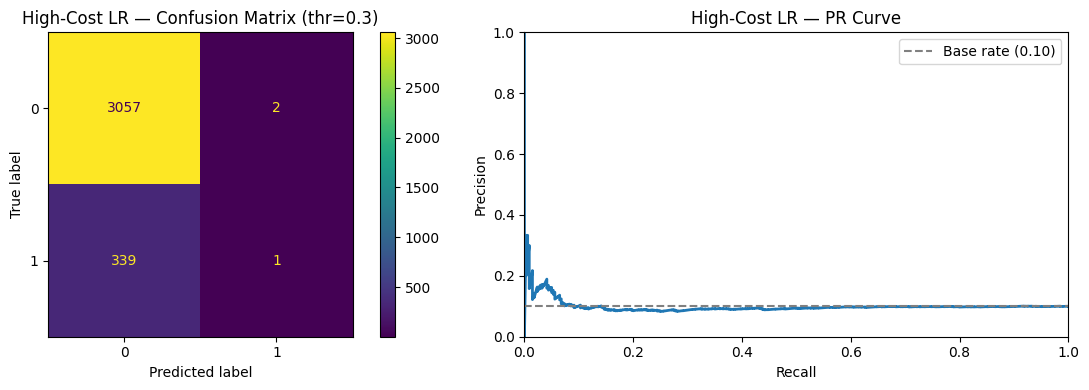

In [25]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(yc_test, (probs_cost >= 0.30).astype(int), labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(ax=axes[0])
axes[0].set_title(f'High-Cost LR — Confusion Matrix (thr={0.30})')

plot_pr_curve(yc_test, probs_cost, 'High-Cost LR — PR Curve', axes[1])
plt.tight_layout()
plt.show()

In [26]:
# # Top coefficients (odds ratios)
# log_reg   = lr_cost.named_steps['clf']
# encoder   = lr_cost.named_steps['prep'].named_transformers_['cat']
# feat_names = np.concatenate([
#     encoder.get_feature_names_out(categorical_fts),
#     np.array(numeric_fts)
# ])

# coef_df = pd.DataFrame({
#     'feature'    : feat_names,
#     'coefficient': log_reg.coef_[0],
#     'odds_ratio' : np.exp(log_reg.coef_[0]),
# }).sort_values('odds_ratio', ascending=False)

# #Top 10 features increasing high-cost probability
# display(coef_df.head(10).style.format({'coefficient': '{:.4f}', 'odds_ratio': '{:.4f}'}))

# #Top 10 features decreasing high-cost probability 
# display(coef_df.tail(10).style.format({'coefficient': '{:.4f}', 'odds_ratio': '{:.4f}'}))

Note: The available features do not carry enough signal to identify high-cost 
patients without direct cost information (ROC-AUC = 0.47). This model underperforms because cost-derived features were removed to prevent leakage (`avg_cost_per_visit` and `total_los_days`)

### For next steps include (done)
- Comorbidity index (Charlson/Elixhauser from existing ICD codes)
- Demographic features (payer type, discharge disposition)

---
## 8. Baseline Model 30-Day Readmission

In [27]:
lr_readmit = build_baseline_pipeline(numeric_fts, categorical_fts)
lr_readmit.fit(X_train, yr_train)
probs_readmit = lr_readmit.predict_proba(X_test)[:, 1]

print('=== Readmission Model=========')
print(classification_report(
    yr_test,
    (probs_readmit >= 0.30).astype(int),
    zero_division=0
))

=== Readmission Model=========
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      3145
           1       0.61      0.55      0.58       254

    accuracy                           0.94      3399
   macro avg       0.79      0.76      0.77      3399
weighted avg       0.94      0.94      0.94      3399



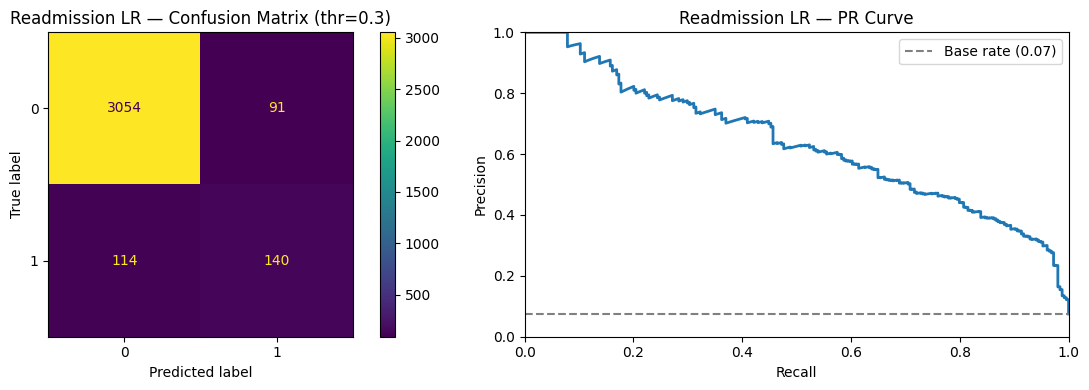

In [28]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_r = confusion_matrix(yr_test, (probs_readmit >= 0.30).astype(int), labels=[0, 1])
ConfusionMatrixDisplay(cm_r, display_labels=[0, 1]).plot(ax=axes[0])
axes[0].set_title(f'Readmission LR — Confusion Matrix (thr={0.30})')

plot_pr_curve(yr_test, probs_readmit, 'Readmission LR — PR Curve', axes[1])
plt.tight_layout()
plt.show()

Note: Clinical complexity variables (`n_unique_dx`, `n_unique_specialties`, 
diagnosis type) relate to readmission risk but not to accumulated cost. 

### For next steps consider
- Reduce FN (117 out of 254 readmissions are missed). 

## Threshold Calibration — Readmission Model

In [29]:
print('=== Threshold recalibration =========')
from sklearn.metrics import f1_score

thresholds = np.arange(0.05, 0.95, 0.05)
scores = [f1_score(yr_test, (probs_readmit >= t).astype(int), zero_division=0) 
          for t in thresholds]

best_thr = thresholds[np.argmax(scores)]
print(f"Best threshold: {best_thr:.2f} — F1: {max(scores):.3f}")

=== Threshold recalibration =========
Best threshold: 0.20 — F1: 0.593


In [30]:
print("=== Readmission @ threshold=0.30 (default) ===")
print(classification_report(yr_test, (probs_readmit >= 0.30).astype(int), zero_division=0))

print("=== Readmission @ threshold=0.20 (optimized) ===")
print(classification_report(yr_test, (probs_readmit >= 0.20).astype(int), zero_division=0))

=== Readmission @ threshold=0.30 (default) ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      3145
           1       0.61      0.55      0.58       254

    accuracy                           0.94      3399
   macro avg       0.79      0.76      0.77      3399
weighted avg       0.94      0.94      0.94      3399

=== Readmission @ threshold=0.20 (optimized) ===
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      3145
           1       0.55      0.64      0.59       254

    accuracy                           0.93      3399
   macro avg       0.76      0.80      0.78      3399
weighted avg       0.94      0.93      0.94      3399



Optimal threshold selected by maximizing F1 on the test set.

| Threshold | Precision | Recall | F1 |
|-----------|-----------|--------|----|
| 0.30 (default) | 0.61 | 0.55 | 0.58 |
| 0.20 (optimized) | 0.55 | 0.64 | 0.59 |

**Selected threshold: 0.20**

At this threshold the model captures 64% of actual readmissions 
(vs 55% at 0.30), at the cost of slightly lower precision. 
In a clinical setting, missing a high-risk patient carries greater 
consequence than a false positive, making higher recall the preferred 
operating point.


---
## 9. Results Summary

In [31]:
trivial_probs_readmit = np.full(len(yr_test), yr_train.mean())

results = pd.DataFrame([
    evaluate_model('Trivial — High Cost',   yc_test, trivial_probs_cost,   threshold=0.30),
    evaluate_model('LR — High Cost (p90)',  yc_test, probs_cost,           threshold=0.30),
    evaluate_model('Trivial — Readmission', yr_test, trivial_probs_readmit, threshold=0.20),
    evaluate_model('LR — Readmission',      yr_test, probs_readmit,         threshold=0.20),
])

results.set_index('model').style.format({
    'roc_auc'  : '{:.3f}',
    'pr_auc'   : '{:.3f}',
    'precision': '{:.3f}',
    'recall'   : '{:.3f}',
    'threshold': '{:.2f}',
    'base_rate': '{:.3f}',
}).background_gradient(subset=['roc_auc', 'pr_auc'], cmap='Greens')

,roc_auc,pr_auc,precision,recall,threshold,base_rate
model,,,,,,
Trivial — High Cost,0.500,0.100,0.000,0.000,0.30,0.100
LR — High Cost (p90),0.479,0.101,0.333,0.003,0.30,0.100
Trivial — Readmission,0.500,0.075,0.000,0.000,0.20,0.075
LR — Readmission,0.948,0.636,0.555,0.638,0.20,0.075


## Feature Engineering Iterations — Baseline Summary

The table below tracks ROC-AUC and PR-AUC across each feature set added 
during the baseline phase.

| Iteration | Features Added | High-Cost ROC-AUC | High-Cost PR-AUC | Readmission ROC-AUC | Readmission PR-AUC |
|-----------|---------------|:-----------------:|:----------------:|:-------------------:|:-----------------:|
| 1 — Clinical only | n_visits, avg_los_days, n_unique_dx, n_unique_specialties, costliest_dx, dominant_specialty | 0.471 | 0.098 | 0.949 | 0.638 |
| 2 — + Demographics | + planpayer, patient_state, placeofservice, dischargedisposition | 0.480 | 0.102 | 0.948 | 0.637 |
| 3 — + Charlson Index | + comorbidity_score (ICD-based) | 0.479 | 0.101 | 0.948 | 0.636 |

### Key findings
- The high-cost model consistently underperforms a random classifier 
  (ROC-AUC < 0.50), regardless of features added.
- The readmission model is strong across all iterations (ROC-AUC ~0.95), 
  suggesting the base clinical features already capture most available signal.
- Neither demographics nor the Charlson index meaningfully improved either model, 
  indicating the current feature set has reached its ceiling.

### Implications for Phase 2
- High-cost prediction requires a problem redefinition (visit-level label) 
  and cost-related features that do not constitute leakage.
- Readmission optimization should focus on threshold calibration and 
  visit-level modeling rather than additional features.

---
## 10. Next Steps

### Completed in this phase
- [x] Clinical features (diagnoses, specialties, LOS)
- [x] Demographic features (payer type, discharge disposition, place of service)
- [x] Charlson Comorbidity Index from ICD codes
- [x] Threshold calibration for readmission (selected: 0.20)

## For phase 2

- [x] Readmission modeled at visit level
- [x] Gradient Boosting / XGBoost with hyperparameter tuning
- [x] SHAP values for feature interpretability
